# Imports

In [33]:
%load_ext autoreload
%autoreload 2
import time

import jax
import matplotlib.pyplot as plt

from eci.adapter import SimulationAdapter
from eci.environment import Environment
from eci.visualizer import SimulationVisualizer
from eci.voting_system.quadratic import _vote_quadratic

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Parameters

In [34]:
NUM_VOTERS = 100
NUM_CANDIDATES = 3
NUM_PREFERENCES = 3
NUM_SIMULATIONS = 50  # the node trajectories

# Environment

In [35]:
env = Environment(
    num_voters=NUM_VOTERS,
    num_candidates=NUM_CANDIDATES,
    num_preferences=NUM_PREFERENCES,
)
env.num_simulations = NUM_SIMULATIONS

# Network

In [36]:
env.initialize_network()

# Simulation

## Quadratic voting

In [37]:
# intiatialize random key
key = jax.random.PRNGKey(int(time.time()))
# run n simulations
sim = env.run_n_simulation(_vote_quadratic, key, NUM_SIMULATIONS)
env._update_agents()

## Random vote

In [38]:
# intiatialize random key
# key = jax.random.PRNGKey(int(time.time()))
# run n simulations
# sim = env.run_n_simulation(_vote_random, key, NUM_SIMULATIONS)
# env._update_agents()

## Plurality

In [39]:
# intiatialize random key
## run n simulations
# sim = env.run_n_simulation(_vote_plurality, key, NUM_SIMULATIONS)
# update the agents with the results
# env._update_agents()

In [40]:
# use result to create dataframe for plotting
env.df = env.create_data_frame()

# Plots

In [41]:
# 1. Initialisation viz and adapter
viz = SimulationVisualizer()
adapter = SimulationAdapter()

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_86600/1607318703.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


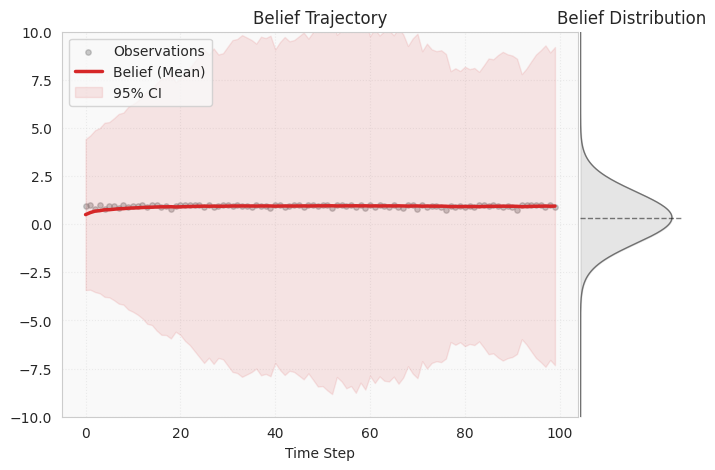

In [42]:
traj_data = adapter.get_voter_trajectory_data(env, voter_id=11)
fig, ax1, ax2 = viz.plot_belief_trajectory(
    **traj_data,
    ylim=(-10, 10),
)
ax1.set_title("Belief Trajectory")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
ax2.set_title("Belief Distribution")
fig.set_size_inches(8, 5)
plt.show()

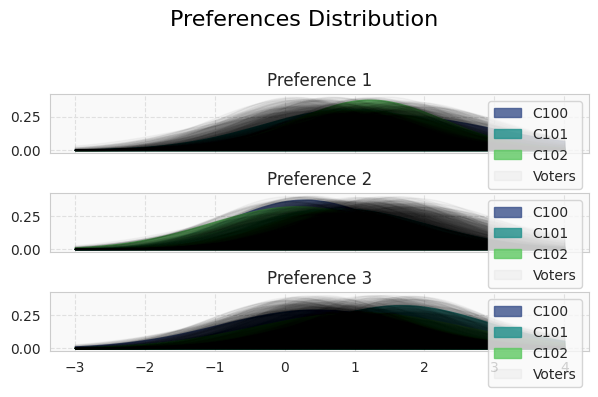

In [43]:
pref_data = adapter.prepare_preference_data(env)
fig, ax1 = viz.plot_preference_distributions(pref_data)
fig.suptitle("Preferences Distribution", fontsize=16)
ax1[0].set_title("Preference 1")
ax1[1].set_title("Preference 2")
ax1[2].set_title("Preference 3")
fig.set_size_inches(6, 4)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

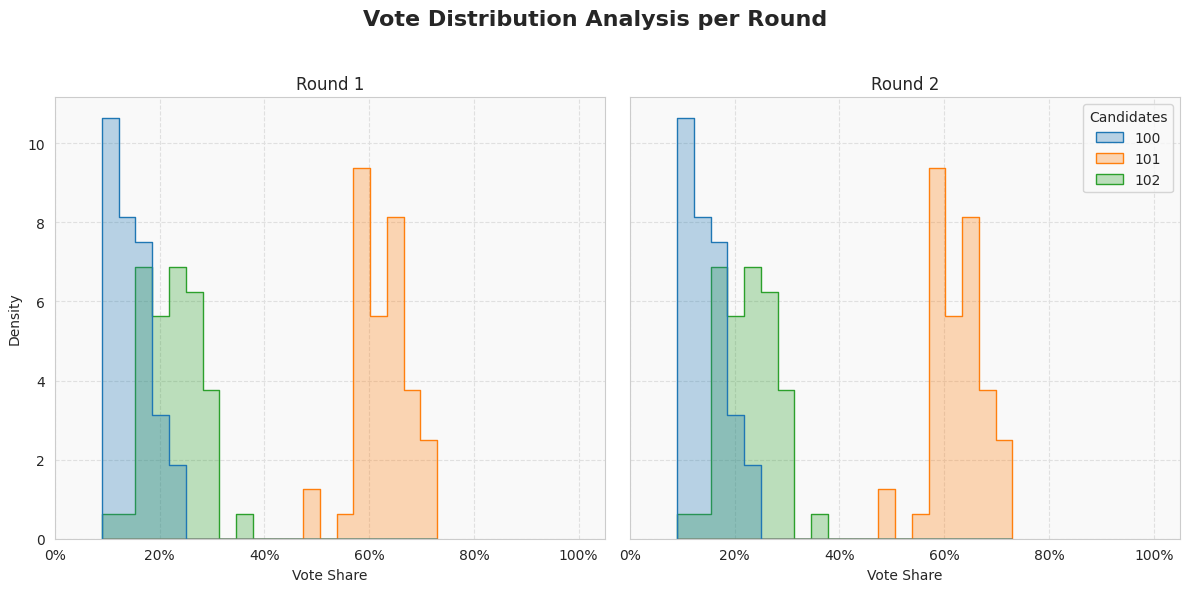

In [44]:
votes_data = adapter.extract_vote_counts(env.df)
fig, axes = viz.plot_vote_proportions(votes_data)
plt.show()